# Notebook 2 — Batch synthesis for detection training

**Workshop path:** [NB0](00_flight_precheck.ipynb) · [NB1](01_sample_data_generation.ipynb) · **this notebook** · [NB3](03_training_and_evaluation.ipynb).

Scale Notebook 1 from *one seed × a few anomalies* to a **detection training set**:

`EDA → stratified real train/test → batch edit → annotate → judge → export`

Same quality story (fidelity / novelty / usability), but load models once, tqdm progress, and checkpoint/resume for long runs.


---
## Why a careful split?

Notebook 3 asks: *does accepted synth help a detector on **held-out real** photos?*  
If synth seeds or “test” images leak into training, the A/B is fake.

| Split piece | Role |
|-------------|------|
| **Test (real only)** | Frozen holdout for NB3 — never edited |
| **Train real** | Rare tagged photos + scene backgrounds |
| **Synth seeds** | Disjoint **clean** `scene_*` from train (no rare GT) → edit → judge |

Prompt variations + embedding novelty keep accepts from collapsing to copies; box/placement gates keep exports usable.


---
## 0. Setup


In [1]:
from pathlib import Path

from aieng.syn_data.image.bootstrap import bootstrap_project_root
from aieng.syn_data.image.config import load_env


PROJECT_ROOT = bootstrap_project_root()
load_env(PROJECT_ROOT)
print("PROJECT_ROOT =", PROJECT_ROOT)

/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT = /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation


---
## 1. Knobs

| Knob | Meaning |
|------|---------|
| `HARDWARE` | Prefer `gpu_l4` / `gpu_l4x2` |
| `METHOD_BY_ANOMALY` | Usually `instruct` from NB0.5 |
| `TEST_COUNTS` | Real holdout sizes per tag |
| `N_SYNTH_SEEDS` / `TARGET_ACCEPTS` | Edit budget vs early-stop accepts |

> **Dual-GPU footnote:** Jupyter caps process workers to 1 (CUDA+ProcessPool is flaky). For 2×L4 long runs use:
> ```bash
> python scripts/run_nb2_batch.py --hardware gpu_l4x2
> python scripts/run_nb2_batch.py --hardware gpu_l4x2 --resume
> ```


In [2]:
import os


os.environ.setdefault("HF_HUB_DISABLE_XET", "1")


from aieng.syn_data.image.config import load_config
from aieng.syn_data.image.data import get_data_source_info, prepare_sample_images
from aieng.syn_data.image.pipeline import resolve_method_map


DATASET = "mapillary_vistas"
HARDWARE = "gpu_l4x2"

METHOD_BY_ANOMALY = {
    "traffic_cone": "instruct",
    "trash_bin": "instruct",
}
TEST_COUNTS = {"scene": 90, "traffic_cone": 30, "trash_bin": 30}
N_SYNTH_SEEDS = {"traffic_cone": 100, "trash_bin": 100}
TARGET_ACCEPTS = {"traffic_cone": 100, "trash_bin": 100}
MAX_RETRIES = 2
SPLIT_SEED = 42
FOCUS_TAGS = ["scene", "traffic_cone", "trash_bin"]

cfg = load_config(
    start=PROJECT_ROOT,
    overrides=[f"dataset_name={DATASET}", f"hardware={HARDWARE}"],
)
info = get_data_source_info(cfg)
prepare_sample_images(cfg=cfg)
samples_dir = Path(cfg.paths.samples_dir)
output_dir = Path(cfg.paths.outputs_dir) / "nb2"
output_dir.mkdir(parents=True, exist_ok=True)
STEM_PREFIXES = list(cfg.data.get("stem_prefixes") or FOCUS_TAGS)
workshop = list(METHOD_BY_ANOMALY)
method_map = resolve_method_map(METHOD_BY_ANOMALY, workshop, cfg=cfg)

print(f"Dataset={cfg.dataset_name}  Hardware={cfg.hardware.name}")
print(f"Export={output_dir}")
for aid, method in method_map.items():
    print(f"  {aid:16s} → {method}")

/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


Dataset=mapillary_vistas  Hardware=gpu_l4x2
Export=/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb2
  traffic_cone     → instruct
  trash_bin        → instruct


---
## 2. EDA — what did we extract?

Tagged filenames (`traffic_cone_*`, `trash_bin_*`, `scene_*`) plus optional `labels.json` boxes.


Image counts (before split/synth):
  scene              320  ( 74.4%)
  traffic_cone        55  ( 12.8%)
  trash_bin           55  ( 12.8%)
  clean_scene (no rare GT): 286


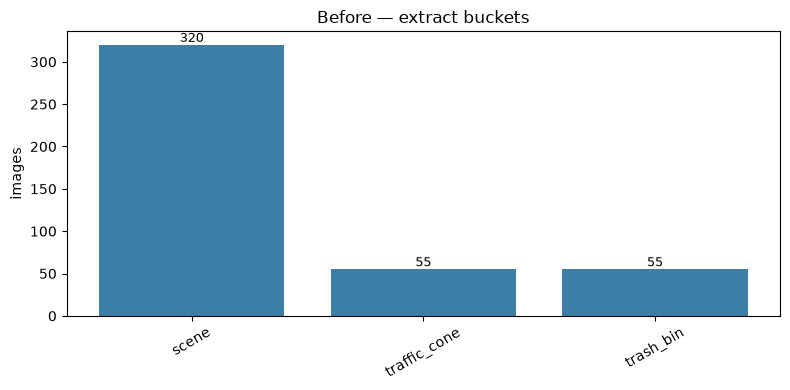

In [3]:
from aieng.syn_data.image.eda import (
    class_image_counts,
    group_by_tag,
    list_tagged_images,
    load_labels_for_dir,
    plot_class_bars,
    summarize_distribution,
)


all_paths = list_tagged_images(samples_dir)
by_tag = group_by_tag(all_paths, tags=FOCUS_TAGS, prefixes=STEM_PREFIXES)
labels = load_labels_for_dir(samples_dir)
before = summarize_distribution(by_tag, focus_tags=FOCUS_TAGS)
print("Image counts (before split/synth):")
for tag, n in before["counts"].items():
    print(f"  {tag:16s}  {n:4d}  ({100 * before['shares'][tag]:5.1f}%)")
clean_counts = class_image_counts(by_tag, labels=labels, rare_classes=workshop)
if "clean_scene" in clean_counts:
    print(f"  clean_scene (no rare GT): {clean_counts['clean_scene']}")
plot_class_bars(before["counts"], title="Before — extract buckets");

---
## 3. Stratified holdout (real test forever)

Clamp requested counts to what exists; keep at least one train image per tag when possible.


Train (real): {'scene': 230, 'traffic_cone': 25, 'trash_bin': 25}
Test  (real): {'scene': 90, 'traffic_cone': 30, 'trash_bin': 30}


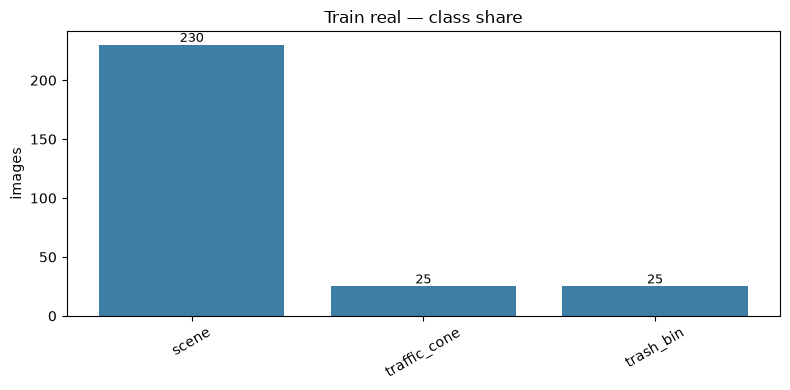

In [4]:
from aieng.syn_data.image.eda import clamp_counts, stratified_holdout, write_json


available = {t: len(by_tag.get(t) or []) for t in FOCUS_TAGS}
test_counts = clamp_counts(TEST_COUNTS, available, min_remaining=1)
if test_counts != TEST_COUNTS:
    print(f"Clamped TEST_COUNTS: {TEST_COUNTS} → {test_counts}")

train_real, test = stratified_holdout(by_tag, test_counts, seed=SPLIT_SEED)
train_summary = summarize_distribution(train_real, focus_tags=FOCUS_TAGS)
test_summary = summarize_distribution(test, focus_tags=FOCUS_TAGS)
print("Train (real):", train_summary["counts"])
print("Test  (real):", test_summary["counts"])
write_json(
    output_dir / "split_summary.json",
    {"test_counts": test_counts, "train_real": train_summary, "test": test_summary, "seed": SPLIT_SEED},
)
plot_class_bars(train_summary["counts"], title="Train real — class share");

---
## 4. Pick disjoint synth seeds

Only **clean** train scenes (no rare GT boxes) so we are not “editing an already-positive” frame.


In [ ]:
from aieng.syn_data.image.eda import allocate_budget, pick_synth_seeds


scene_train = list(train_real.get("scene") or [])
seed_request = allocate_budget(N_SYNTH_SEEDS, len(scene_train))
if seed_request != N_SYNTH_SEEDS:
    print(f"Clamped N_SYNTH_SEEDS: {N_SYNTH_SEEDS} → {seed_request}")

seeds_by_anomaly = pick_synth_seeds(
    scene_train,
    seed_request,
    labels=labels,
    rare_classes=workshop,
    seed=SPLIT_SEED,
)
for aid, paths in seeds_by_anomaly.items():
    print(f"  {aid:16s}  {len(paths)} scene seeds")
target_accepts = {k: min(int(TARGET_ACCEPTS.get(k, len(v))), len(v)) for k, v in seeds_by_anomaly.items()}
print("Target accepts:", target_accepts)

  traffic_cone      100 scene seeds
  trash_bin         100 scene seeds
Target accepts: {'traffic_cone': 100, 'trash_bin': 100}


---
## 5. Batch synthesize + judge

> Runtime on `HARDWARE=gpu_l4x2` with Klein as the generator and gemini as the judge model: ~1hr for 200 generations (~17.5s/img), ~5-10min for 200 judgements(~1.5-2.5s/img), total ~90-120mins with all retries

Expect the longest cell in the workshop — leave it running; tqdm shows progress.

Same loop as NB1, amortized:

- Edit stack loaded once (notebook: 1 GPU worker; CLI: dual-GPU processes).
- API judge fan-out (`judge.max_parallel`).
- Progress: **tqdm** bars + phase summaries (`VERBOSE=False`).
- Gates: target boxes required; placement from anomaly YAML; VLM + embedding safe-zone.


In [6]:
from aieng.syn_data.image.batch_runner import run_batch_synthesis


RESUME = False
VERBOSE = False

synth_dir = output_dir / "synthetic"
batch = run_batch_synthesis(
    seeds_by_anomaly,
    method_map,
    cfg=cfg,
    project_root=PROJECT_ROOT,
    synth_dir=synth_dir,
    max_retries=MAX_RETRIES,
    target_accepts=target_accepts,
    require_target_boxes=True,
    resume=RESUME,
    nb2_dir=output_dir,
    progress="tqdm",
    verbose=VERBOSE,
)

print("\nAcceptance rate per class:")
for aid, st in batch.stats.items():
    print(
        f"  {aid:16s}  accept={st.accepts}/{st.attempts}  "
        f"rate={100 * st.acceptance_rate:5.1f}%  "
        f"reject={st.rejects}  retry_events={st.retries}",
    )
empty = [r for r in batch.rejected if not r.get("has_target_boxes", True)]
if empty:
    print(f"Rejected for missing target boxes: {len(empty)}")

Notebook: edit_workers capped to 1 (use scripts/run_nb2_batch.py for dual-GPU).
Batch parallelism: edit_workers=1  judge_workers=8  depth=False  seg=False
Loading edit stack once (200 jobs)…
Loading edit stack on default device…
  warming Klein instruct on auto…


Editing:   0%|          | 0/200 [00:00<?, ?img/s]/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
Editing: 100%|██████████| 200/200 [57:42<00:00, 17.31s/img]


Switching to judge…
Judging 200 item(s) with 8 parallel API calls…


Judging: 100%|██████████| 200/200 [07:54<00:00,  2.37s/img]


Judge round: accept=103  retry=66  reject=31  accepted_total=103
Retrying 66 item(s)…
Loading edit stack on default device…
  warming Klein instruct on auto…


...

Judge round: accept=27  retry=28  reject=11  accepted_total=130
Retrying 28 item(s)…
Loading edit stack on default device…
  warming Klein instruct on auto…


Editing: 100%|██████████| 28/28 [08:09<00:00, 17.48s/img]


Switching to judge…
Judging 28 item(s) with 8 parallel API calls…


Judging: 100%|██████████| 28/28 [00:46<00:00,  1.66s/img]


Judge round: accept=8  retry=0  reject=20  accepted_total=138
Done. Accepted 138 / 294 attempts.

Acceptance rate per class:
  traffic_cone      accept=49/178  rate= 27.5%  reject=51  retry_events=78
  trash_bin         accept=89/116  rate= 76.7%  reject=11  retry_events=16


---
## 6. Dose preview — real vs real+accepted

This is the **image-count** teaser for Notebook 3’s detector dose–response (AP on held-out real).


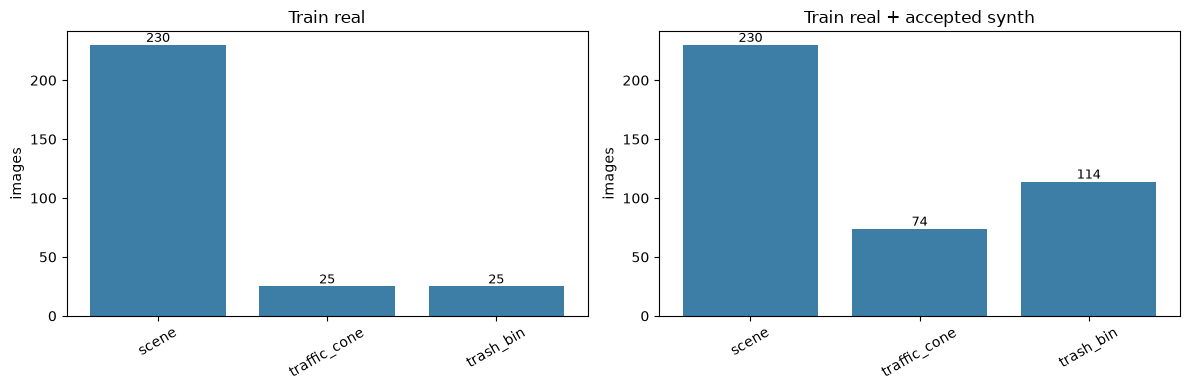

real n=280
  traffic_cone        25  (  8.9%)
  trash_bin           25  (  8.9%)
real+synth n=418
  traffic_cone        74  ( 17.7%)
  trash_bin          114  ( 27.3%)


In [7]:
import matplotlib.pyplot as plt


after_counts = dict(train_summary["counts"])
for sample in batch.accepted:
    after_counts[sample.anomaly_id] = after_counts.get(sample.anomaly_id, 0) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_class_bars(train_summary["counts"], title="Train real", ax=axes[0])
plot_class_bars(after_counts, title="Train real + accepted synth", ax=axes[1])
plt.show()

for split_name, counts in (("real", train_summary["counts"]), ("real+synth", after_counts)):
    total = sum(counts.values()) or 1
    print(f"{split_name} n={total}")
    for cls in workshop:
        n = counts.get(cls, 0)
        print(f"  {cls:16s}  {n:4d}  ({100 * n / total:5.1f}%)")

---
## 7. Export manifests for Notebook 3


In [8]:
from aieng.syn_data.image.batch_export import export_nb2_dataset


config_snapshot = {
    "dataset": DATASET,
    "hardware": HARDWARE,
    "method_by_anomaly": dict(method_map),
    "test_counts": test_counts,
    "n_synth_seeds": seed_request,
    "target_accepts": target_accepts,
    "max_retries": MAX_RETRIES,
    "split_seed": SPLIT_SEED,
    "judge_model": str(cfg.judge.model_id),
    "judge_threshold": float(cfg.judge.threshold),
    "generation_family": str(cfg.generation.family),
}
paths = export_nb2_dataset(
    output_dir=output_dir,
    accepted=batch.accepted,
    train_real=train_real,
    test=test,
    real_labels=labels,
    run_stats=batch.stats,
    config_snapshot=config_snapshot,
)
print("Wrote:")
for key, path in paths.items():
    print(f"  {key:16s}  {path}")
print(f"Accepted synth images: {len(batch.accepted)}")
print("Next: Notebook 3")

Wrote:
  root              /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb2
  synthetic_dir     /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb2/synthetic
  labels            /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb2/labels_synthetic.json
  train_manifest    /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb2/train_manifest.json
  test_manifest     /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb2/test_manifest.json
  run_stats         /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb2/run_stats.json
Accepted synth images: 138
Next: Notebook 3


---
## Wrap-up

You now have `outputs/<dataset>/nb2/train_manifest.json` + `test_manifest.json`. Notebook 3 fine-tunes YOLOv8n on real-only vs real+synth fractions against the **same real test**.
